# Benchmark Models
## Emotion Recognition from Abstract Art
### Three benchmark methods evaluated under identical experimental conditions

Models:
1. ResNet-50 (transfer learning, fine-tuned)
2. SVM on ResNet-50 CNN features
3. Naive Bayes on hand-crafted features (HOG + HSV histogram)

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from src.preprocessing import load_data, get_splits, get_class_weights
from src.dataset import get_dataloaders
from src.train import train
from src.evaluate import evaluate
from src.model_benchmarks import (
    get_resnet50,
    get_feature_extractor, extract_features, train_svm,
    extract_handcrafted_features, train_naive_bayes
)

In [2]:
# Device & Data Setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

df, le = load_data("../data/dataset_final.csv")
train_df, val_df, test_df = get_splits(df, subset_size=3000)
class_weights = get_class_weights(train_df, device)

IMAGE_DIR = "../data/images"
train_loader, val_loader, test_loader = get_dataloaders(train_df, val_df, test_df, IMAGE_DIR)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Using device: mps
Train: 2400 | Val: 300 | Test: 300


## Benchmark 1: ResNet-50 (Transfer Learning)
Pretrained ResNet-50 with replaced classification head, fine-tuned with class-weighted loss.

Serves as the primary deep CNN baseline to compare against ViT.

In [3]:
# ResNet-50 Model
resnet_model = get_resnet50(num_classes=8).to(device)

dummy = torch.randn(2, 3, 224, 224).to(device)
out = resnet_model(dummy)
print(f"Output shape: {out.shape}")

total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Output shape: torch.Size([2, 8])
Total parameters: 23,524,424
Trainable parameters: 23,524,424


In [9]:
# Train ResNet-50
resnet_history = train(
    resnet_model, train_loader, val_loader,
    class_weights, device,
    epochs=5,
    save_path="../models/best_resnet50.pth"
)

Epoch 1/5 | Train Loss: 2.0259 | Train Acc: 0.2004 | Val Loss: 2.1264 | Val Acc: 0.1367
Epoch 2/5 | Train Loss: 1.7832 | Train Acc: 0.2467 | Val Loss: 2.3494 | Val Acc: 0.1833
Epoch 3/5 | Train Loss: 1.4326 | Train Acc: 0.3438 | Val Loss: 2.5382 | Val Acc: 0.2333
Epoch 4/5 | Train Loss: 1.0799 | Train Acc: 0.4542 | Val Loss: 2.8375 | Val Acc: 0.1767
Epoch 5/5 | Train Loss: 0.7689 | Train Acc: 0.5713 | Val Loss: 2.8183 | Val Acc: 0.2333


## Benchmark 2: SVM on ResNet-50 CNN Features
Penultimate layer features from frozen ResNet-50 fed into a radial-basis SVM classifier.

Separates feature extraction from classification to test whether CNN features alone are sufficient.

In [7]:
# Extract & Train SVM
print("Extracting features...")
feature_extractor = get_feature_extractor(device)

X_train, y_train = extract_features(train_loader, feature_extractor, device)
X_val, y_val = extract_features(val_loader, feature_extractor, device)

print(f"Train features shape: {X_train.shape}")
print(f"Val features shape: {X_val.shape}")

Extracting features...
Train features shape: (2400, 2048)
Val features shape: (300, 2048)


In [10]:
# Train SVM
print("Training SVM...")
svm_model, scaler = train_svm(X_train, y_train)

X_val_scaled = scaler.transform(X_val)
svm_val_acc = svm_model.score(X_val_scaled, y_val)
print(f"SVM Val Accuracy: {svm_val_acc:.4f}")

Training SVM...
SVM Val Accuracy: 0.3433


## Benchmark 3: Naive Bayes on Hand-Crafted Features
HSV colour histogram + HOG descriptors fed into GaussianNB.

Classical lower-bound baseline, tests whether traditional computer vision

features can capture emotional content without deep learning.

In [11]:
print("Extracting hand-crafted features...")
X_train_hc, y_train_hc = extract_handcrafted_features(train_df, IMAGE_DIR)
X_val_hc, y_val_hc = extract_handcrafted_features(val_df, IMAGE_DIR)
print(f"Feature shape: {X_train_hc.shape}")

Extracting hand-crafted features...


100%|██████████| 300/300 [00:37<00:00,  8.10it/s]

Feature shape: (2400, 1664)


In [12]:
nb_model = train_naive_bayes(X_train_hc, y_train_hc)
nb_val_acc = nb_model.score(X_val_hc, y_val_hc)
print(f"Naive Bayes Val Accuracy: {nb_val_acc:.4f}")

Naive Bayes Val Accuracy: 0.1633


In [ ]:
# Results Summary
print("=" * 50)
print("Benchmark Results Summary (Val Accuracy)")
print("=" * 50)
print(f"ResNet-50 (transfer learning): {max(resnet_history['val_acc']):.4f}")
print(f"SVM on CNN features:           {svm_val_acc:.4f}")
print(f"Naive Bayes (HOG + HSV):       {nb_val_acc:.4f}")
print("=" * 50)
print("Note: 3k subset smoke test, final results on 15k via Colab")

Benchmark Results Summary (Val Accuracy)
ResNet-50 (transfer learning): 0.2333
SVM on CNN features:           0.3433
Naive Bayes (HOG + HSV):       0.1633
Note: 3k subset smoke test, final results on 15k via Colab


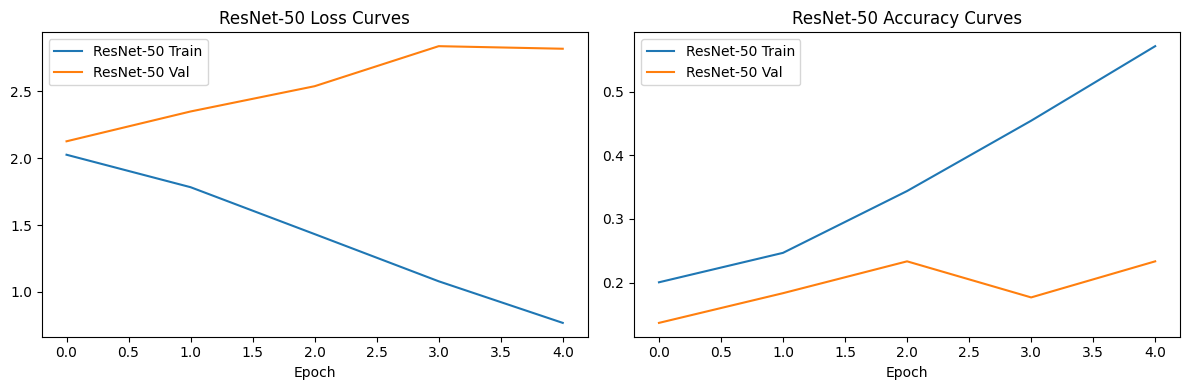

In [14]:
# Training Curves ResNet-50
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(resnet_history['train_loss'], label='ResNet-50 Train')
axes[0].plot(resnet_history['val_loss'], label='ResNet-50 Val')
axes[0].set_title('ResNet-50 Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(resnet_history['train_acc'], label='ResNet-50 Train')
axes[1].plot(resnet_history['val_acc'], label='ResNet-50 Val')
axes[1].set_title('ResNet-50 Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/resnet50_training_curves.png")
plt.show()

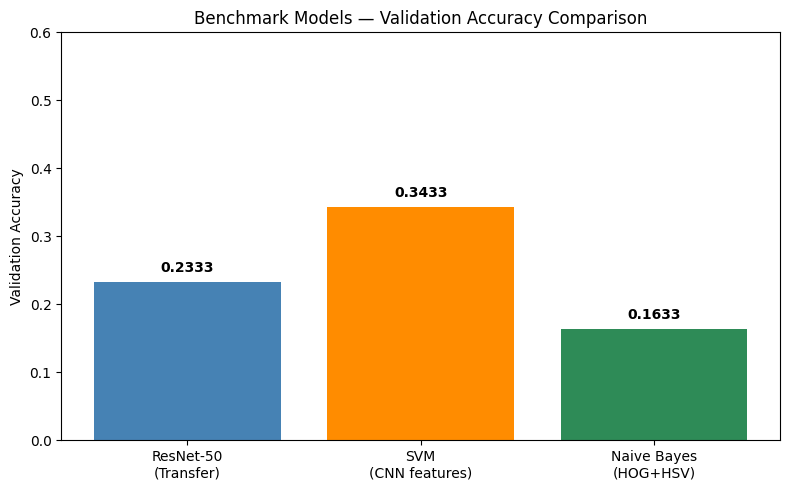

In [15]:
# Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))

models_names = ['ResNet-50\n(Transfer)', 'SVM\n(CNN features)', 'Naive Bayes\n(HOG+HSV)']
val_accs = [max(resnet_history['val_acc']), svm_val_acc, nb_val_acc]

bars = ax.bar(models_names, val_accs, color=['steelblue', 'darkorange', 'seagreen'])
ax.set_title('Benchmark Models — Validation Accuracy Comparison')
ax.set_ylabel('Validation Accuracy')
ax.set_ylim(0, 0.6)

for bar, acc in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("../results/benchmark_comparison.png")
plt.show()